# Q1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01

# system equations
def deriv(state):
    xi, v = state
    return np.array([v, -xi + xi**2])

# RK4 step
def rk4(state):
    k1 = deriv(state)
    k2 = deriv(state + 0.5 * dt * k1)
    k3 = deriv(state + 0.5 * dt * k2)
    k4 = deriv(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# energy function
def energy(xi, v):
    return 0.5 * v**2 + 0.5 * xi**2 - (1.0/3.0) * xi**3

# simulation
def simulate(xi0, v0, tmax, stop_on_escape=False):
    xi_vals, v_vals, E_vals, t_vals = [], [], [], []

    state = np.array([xi0, v0])
    t = 0.0

    while t <= tmax:
        xi, v = state

        xi_vals.append(xi)
        v_vals.append(v)
        E_vals.append(energy(xi, v))
        t_vals.append(t)

        if stop_on_escape and xi > 5:
            break

        state = rk4(state)
        t += dt

    return np.array(t_vals), np.array(xi_vals), np.array(v_vals), np.array(E_vals)

In [2]:
# run cases 
tA, xiA, vA, EA = simulate(0.3, 0.0, 50)
tB, xiB, vB, EB = simulate(0.9, 0.0, 50)
tC, xiC, vC, EC = simulate(0.3, 0.6, 100, stop_on_escape=True)

# energy check 

err_A = np.max(np.abs(EA - EA[0]))
err_B = np.max(np.abs(EB - EB[0]))

print("Max energy drift (A):", err_A)
print("Max energy drift (B):", err_B)

Max energy drift (A): 3.1402311306827357e-12
Max energy drift (B): 2.831920808965549e-11


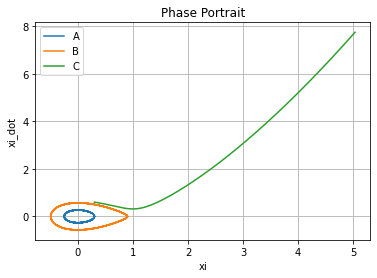

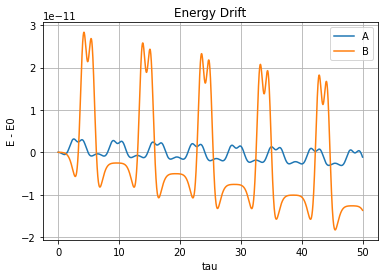

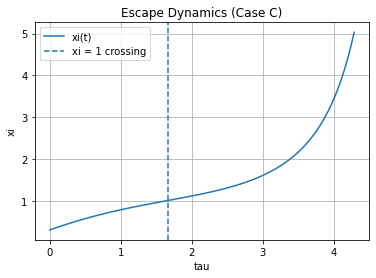

In [3]:
# plots 

# phase portrait
plt.figure()
plt.plot(xiA, vA, label='A')
plt.plot(xiB, vB, label='B')
plt.plot(xiC, vC, label='C')
plt.xlabel("xi")
plt.ylabel("xi_dot")
plt.title("Phase Portrait")
plt.legend()
plt.grid()

# energy drift
plt.figure()
plt.plot(tA, EA - EA[0], label='A')
plt.plot(tB, EB - EB[0], label='B')
plt.xlabel("tau")
plt.ylabel("E - E0")
plt.title("Energy Drift")
plt.legend()
plt.grid()

# escape plot
plt.figure()
plt.plot(tC, xiC, label='xi(t)')

cross_idx = None
for i in range(len(xiC)):
    if xiC[i] > 1:
        cross_idx = i
        break

if cross_idx is not None:
    plt.axvline(tC[cross_idx], linestyle='--', label='xi = 1 crossing')

plt.xlabel("tau")
plt.ylabel("xi")
plt.title("Escape Dynamics (Case C)")
plt.legend()
plt.grid()

plt.show()